Dataset Loaded Successfully
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

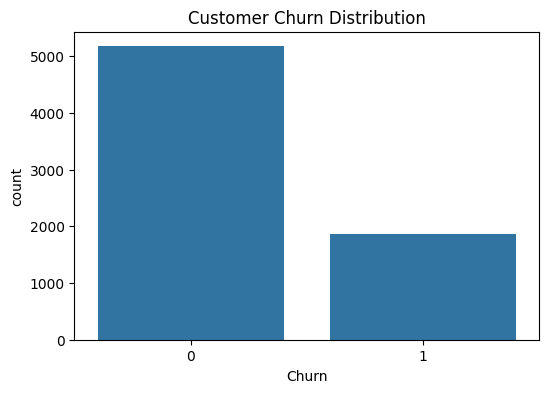

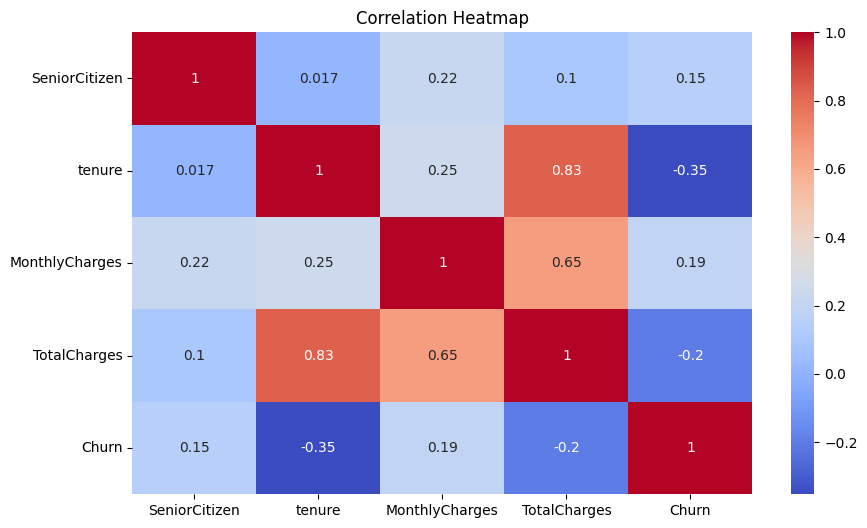


Numeric Features
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train Shape: (5634, 19)
Test Shape: (1409, 19)

Training Logistic Regression

Training Random Forest

LOGISTIC REGRESSION RESULTS

Accuracy : 0.8048261178140526
Precision: 0.6551724137931034
Recall   : 0.5588235294117647
F1 Score : 0.6031746031746031

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



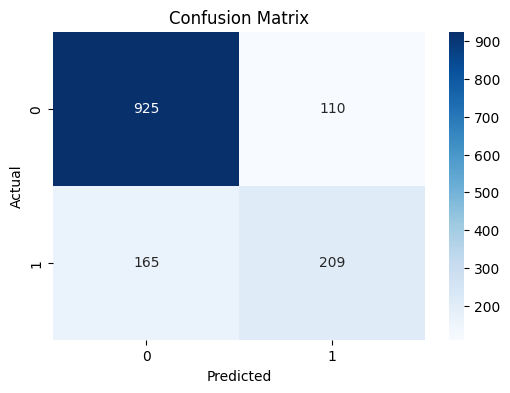


RANDOM FOREST RESULTS

Accuracy : 0.8026969481902059
Precision: 0.66
Recall   : 0.5294117647058824
F1 Score : 0.5875370919881305

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



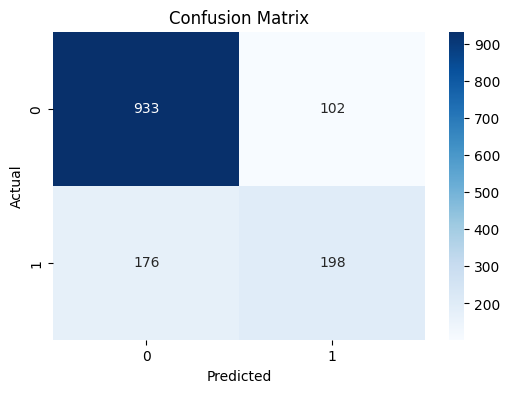


Model Saved Successfully

FINAL BEST MODEL SUMMARY
Best Model:
Logistic Regression

Best Parameters:
{'classifier__C': 10, 'classifier__solver': 'liblinear'}

Accuracy:
0.8048

F1 Score:
0.6032

Saved File:
best_churn_pipeline.pkl


In [9]:
# ==========================================================
# TASK 2: END-TO-END ML PIPELINE WITH SCIKIT-LEARN
# CUSTOMER CHURN PREDICTION
# ==========================================================

# ==========================
# IMPORT LIBRARIES
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

display(df.head())

# ==========================
# DATA UNDERSTANDING
# ==========================

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ==========================
# DATA CLEANING
# ==========================

# Remove customerID
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Convert target column
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("\nData Cleaning Completed")

# ==========================
# VISUALIZATION 1
# CHURN DISTRIBUTION
# ==========================

plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

# ==========================
# CORRELATION HEATMAP
# ==========================

numeric_columns = df.select_dtypes(
    include=["int64","float64"]
).columns

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================
# FEATURES AND TARGET
# ==========================

X = df.drop("Churn", axis=1)
y = df["Churn"]

# ==========================
# FEATURE TYPES
# ==========================

numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumeric Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

# ==========================
# NUMERIC PIPELINE
# ==========================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ==========================
# CATEGORICAL PIPELINE
# ==========================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# ==========================
# COLUMN TRANSFORMER
# ==========================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==========================================================
# LOGISTIC REGRESSION PIPELINE
# ==========================================================

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=5000
            )
        )
    ]
)

lr_parameters = {
    "classifier__C":[0.01,0.1,1,10],
    "classifier__solver":["liblinear"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_parameters,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("\nTraining Logistic Regression")

lr_grid.fit(
    X_train,
    y_train
)

# ==========================================================
# RANDOM FOREST PIPELINE
# ==========================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

rf_parameters = {
    "classifier__n_estimators":[100],
    "classifier__max_depth":[5,10],
    "classifier__min_samples_split":[2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_parameters,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("\nTraining Random Forest")

rf_grid.fit(
    X_train,
    y_train)

# ==========================================================
# EVALUATION FUNCTION
# ==========================================================

def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            predictions
        )
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    return accuracy, f1

# ==========================================================
# LOGISTIC REGRESSION RESULTS
# ==========================================================

print("\n============================")
print("LOGISTIC REGRESSION RESULTS")
print("============================")

lr_accuracy, lr_f1 = evaluate_model(
    lr_grid.best_estimator_,
    X_test,
    y_test
)

# ==========================================================
# RANDOM FOREST RESULTS
# ==========================================================

print("\n========================")
print("RANDOM FOREST RESULTS")
print("========================")

rf_accuracy, rf_f1 = evaluate_model(
    rf_grid.best_estimator_,
    X_test,
    y_test
)

# ==========================================================
# BEST MODEL SELECTION
# ==========================================================

if rf_f1 > lr_f1:

    best_model = rf_grid.best_estimator_
    best_name = "Random Forest"
    best_params = rf_grid.best_params_
    best_accuracy = rf_accuracy
    best_f1 = rf_f1

else:

    best_model = lr_grid.best_estimator_
    best_name = "Logistic Regression"
    best_params = lr_grid.best_params_
    best_accuracy = lr_accuracy
    best_f1 = lr_f1

# ==========================================================
# SAVE FINAL MODEL
# ==========================================================

joblib.dump(
    best_model,
    "best_churn_pipeline.pkl"
)

print("\nModel Saved Successfully")

# ==========================================================
# FINAL RESULTS
# ==========================================================

print("\n===================================")
print("FINAL BEST MODEL SUMMARY")
print("===================================")

print("Best Model:")
print(best_name)

print("\nBest Parameters:")
print(best_params)

print("\nAccuracy:")
print(round(best_accuracy,4))

print("\nF1 Score:")
print(round(best_f1,4))

print("\nSaved File:")
print("best_churn_pipeline.pkl")

In [10]:
loaded_model = joblib.load("best_churn_pipeline.pkl")

sample_prediction = loaded_model.predict(X_test.iloc[:5])

print("Sample Predictions:")
print(sample_prediction)

Sample Predictions:
[0 1 0 0 0]


In [11]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "F1 Score": [lr_f1, rf_f1]
})

print(comparison)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.804826  0.603175
1        Random Forest  0.802697  0.587537
